# Deterministic vs. Stochastic GridWorld: Reinforcement Learning Foundations

This notebook combines the deterministic and stochastic 7×7 GridWorld examples into one progression.

The same state space, action space, reward structure, start state, goal state, and obstacles are used in both environments. The only difference is the **transition model**:

- **Deterministic:** the intended action occurs with probability $1$.
- **Stochastic:** the intended action occurs with probability $0.80$, while the two perpendicular slip actions occur with probability $0.10$ each.

This makes it possible to compare how transition uncertainty changes trajectories, state values, action values, Bellman backups, and optimal policies.

A central distinction throughout the notebook is

$$
\boxed{
\text{Policy randomness} \neq \text{Environment randomness}
}
$$

## 1. Imports and Reproducibility

In [1]:
import random
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 2. Shared 7×7 GridWorld

Both environments use the same GridWorld:

- Start state: $(0,0)$
- Goal state: $(6,6)$
- Actions: `Up`, `Down`, `Left`, `Right`
- Regular step reward: $-1$
- Attempt to enter an obstacle: $-5$
- Reaching the goal: $+10$
- Terminal-state reward after arrival: $0$

The stochastic model extends the deterministic model by introducing uncertainty in how an intended action is executed.

In [2]:
class GridworldMDP:
    def __init__(self, size=7, gamma=0.9, intended_prob=1.0, seed=42):
        if not 0 < intended_prob <= 1:
            raise ValueError("intended_prob must be in (0, 1].")

        self.size = size
        self.gamma = gamma
        self.intended_prob = intended_prob
        self.slip_prob = (1.0 - intended_prob) / 2.0
        self.rng = np.random.default_rng(seed)

        self.start_state = (0, 0)
        self.goal_state = (6, 6)
        self.obstacles = {(2, 2), (3, 3), (4, 4), (5, 2), (1, 5)}
        self.action_space = ("Up", "Down", "Left", "Right")

        self.state_space = [
            (row, col)
            for row in range(size)
            for col in range(size)
            if (row, col) not in self.obstacles
        ]

        self.slip_actions = {
            "Up": ("Left", "Right"),
            "Down": ("Right", "Left"),
            "Left": ("Down", "Up"),
            "Right": ("Up", "Down"),
        }

        self.state = self.start_state

    def reset(self, state=None, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)

        if state is None:
            state = self.start_state

        if state not in self.state_space:
            raise ValueError("Reset state must be a valid non-obstacle state.")

        self.state = state
        return self.state

    def _movement_result(self, state, actual_action):
        if state == self.goal_state:
            return self.goal_state, 0, True

        row, col = state

        if actual_action == "Up":
            candidate = (max(row - 1, 0), col)
        elif actual_action == "Down":
            candidate = (min(row + 1, self.size - 1), col)
        elif actual_action == "Left":
            candidate = (row, max(col - 1, 0))
        elif actual_action == "Right":
            candidate = (row, min(col + 1, self.size - 1))
        else:
            raise ValueError("Invalid action.")

        if candidate in self.obstacles:
            return state, -5, False

        if candidate == self.goal_state:
            return candidate, 10, True

        return candidate, -1, False

    def transition_distribution(self, state, intended_action):
        if state not in self.state_space:
            raise ValueError("State must be a valid non-obstacle state.")

        if intended_action not in self.action_space:
            raise ValueError("Invalid action.")

        if state == self.goal_state:
            return [(1.0, self.goal_state, 0, True)]

        if self.intended_prob == 1.0:
            movement_options = [(1.0, intended_action)]
        else:
            slip_1, slip_2 = self.slip_actions[intended_action]
            movement_options = [
                (self.intended_prob, intended_action),
                (self.slip_prob, slip_1),
                (self.slip_prob, slip_2),
            ]

        aggregated = defaultdict(float)

        for probability, actual_action in movement_options:
            next_state, reward, done = self._movement_result(state, actual_action)
            aggregated[(next_state, reward, done)] += probability

        distribution = [
            (probability, next_state, reward, done)
            for (next_state, reward, done), probability in aggregated.items()
        ]

        return sorted(distribution, key=lambda x: (x[1], x[2], x[3]))

    def transition_probability(self, state, action, next_state):
        return sum(
            probability
            for probability, candidate_state, _, _ in self.transition_distribution(state, action)
            if candidate_state == next_state
        )

    def expected_reward(self, state, action):
        return sum(
            probability * reward
            for probability, _, reward, _ in self.transition_distribution(state, action)
        )

    def step(self, intended_action):
        distribution = self.transition_distribution(self.state, intended_action)
        probabilities = [item[0] for item in distribution]
        index = self.rng.choice(len(distribution), p=probabilities)

        probability, next_state, reward, done = distribution[index]
        previous_state = self.state
        self.state = next_state

        return next_state, reward, done, {
            "previous_state": previous_state,
            "intended_action": intended_action,
            "sampled_outcome_probability": probability,
        }

    def plot(self, state=None, title="7×7 GridWorld"):
        if state is None:
            state = self.state

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.set_xlim(-0.5, self.size - 0.5)
        ax.set_ylim(self.size - 0.5, -0.5)
        ax.set_xticks(range(self.size))
        ax.set_yticks(range(self.size))
        ax.set_xticks(np.arange(-0.5, self.size, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, self.size, 1), minor=True)
        ax.grid(which="minor", linewidth=1)
        ax.tick_params(which="minor", bottom=False, left=False)

        for row in range(self.size):
            for col in range(self.size):
                position = (row, col)

                if position in self.obstacles:
                    label = "X"
                elif position == self.goal_state:
                    label = "G"
                elif position == self.start_state:
                    label = "S"
                else:
                    label = ""

                if label:
                    ax.text(col, row, label, ha="center", va="center", fontsize=14)

        if state != self.goal_state:
            ax.text(state[1], state[0], "A", ha="center", va="center", fontsize=14)

        ax.set_xlabel("Column")
        ax.set_ylabel("Row")
        ax.set_title(title)
        plt.show()

Valid states: 44
Action space: ('Up', 'Down', 'Left', 'Right')
Start state: (0, 0)
Goal state: (6, 6)
Obstacles: [(1, 5), (2, 2), (3, 3), (4, 4), (5, 2)]

Deterministic intended probability: 1.0
Stochastic intended probability: 0.8
Stochastic slip probability: 0.09999999999999998


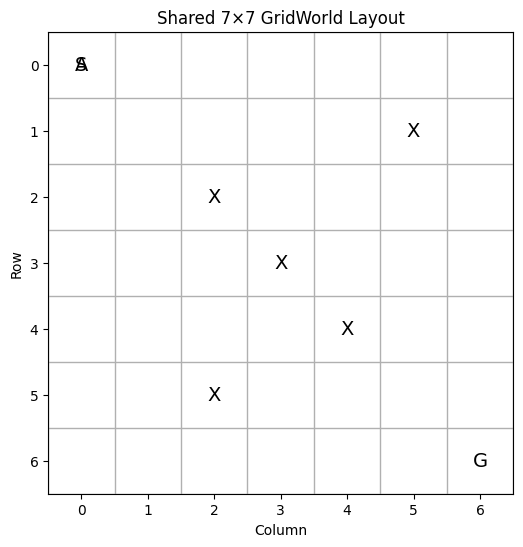

In [3]:
det_env = GridworldMDP(intended_prob=1.0, seed=SEED)
stoch_env = GridworldMDP(intended_prob=0.8, seed=SEED)

print("Valid states:", len(det_env.state_space))
print("Action space:", det_env.action_space)
print("Start state:", det_env.start_state)
print("Goal state:", det_env.goal_state)
print("Obstacles:", sorted(det_env.obstacles))
print()
print("Deterministic intended probability:", det_env.intended_prob)
print("Stochastic intended probability:", stoch_env.intended_prob)
print("Stochastic slip probability:", stoch_env.slip_prob)

det_env.plot(title="Shared 7×7 GridWorld Layout")

## 3. Markov Decision Process

A finite Markov Decision Process can be represented as

$$
\mathcal{M}=(\mathcal{S},\mathcal{A},P,R,\gamma),
$$

where:

- $\mathcal{S}$ is the state space,
- $\mathcal{A}$ is the action space,
- $P(s'|s,a)$ describes the transition model,
- $R$ describes immediate rewards,
- $\gamma$ is the discount factor.

The deterministic and stochastic GridWorlds differ only in $P(s'|s,a)$.

### Deterministic transition

For each state-action pair, exactly one next state occurs:

$$
P(s'|s,a)=
\begin{cases}
1, & s'=f(s,a),\\
0, & \text{otherwise}.
\end{cases}
$$

### Stochastic transition

Several next states can have nonzero probability:

$$
0\le P(s'|s,a)\le 1,
\qquad
\sum_{s'}P(s'|s,a)=1.
$$

In [4]:
state = (4, 1)
action = "Up"

print("Deterministic transition distribution")
for probability, next_state, reward, done in det_env.transition_distribution(state, action):
    print(f"  P={probability:.2f} -> {next_state}, reward={reward}, done={done}")

print("\nStochastic transition distribution")
for probability, next_state, reward, done in stoch_env.transition_distribution(state, action):
    print(f"  P={probability:.2f} -> {next_state}, reward={reward}, done={done}")

print("\nProbability sums")
print("  Deterministic:", sum(x[0] for x in det_env.transition_distribution(state, action)))
print("  Stochastic:", sum(x[0] for x in stoch_env.transition_distribution(state, action)))

Deterministic transition distribution
  P=1.00 -> (3, 1), reward=-1, done=False

Stochastic transition distribution
  P=0.80 -> (3, 1), reward=-1, done=False
  P=0.10 -> (4, 0), reward=-1, done=False
  P=0.10 -> (4, 2), reward=-1, done=False

Probability sums
  Deterministic: 1.0
  Stochastic: 1.0


## 4. The Markov Property

The Markov property states that, given the current state and action, the distribution of the next state does not require the complete past history:

$$
P(S_{t+1}\mid S_t,A_t,S_{t-1},A_{t-1},\ldots)
=
P(S_{t+1}\mid S_t,A_t).
$$

The Markov property does **not** require deterministic behavior. A stochastic environment can still be Markov as long as its next-state distribution is determined by the current state and action.

In [5]:
state = (4, 1)
action = "Up"
trials = 5000
counts = Counter()

stoch_env.reset(state, seed=SEED)

for _ in range(trials):
    stoch_env.state = state
    next_state, reward, done, info = stoch_env.step(action)
    counts[(next_state, reward)] += 1

print("Theoretical distribution:")
for probability, next_state, reward, done in stoch_env.transition_distribution(state, action):
    print(f"  {next_state}, reward={reward}: P={probability:.2f}")

print(f"\nEmpirical frequencies from {trials:,} samples:")
for (next_state, reward), count in sorted(counts.items()):
    print(f"  {next_state}, reward={reward}: {count / trials:.3f}")

Theoretical distribution:
  (3, 1), reward=-1: P=0.80
  (4, 0), reward=-1: P=0.10
  (4, 2), reward=-1: P=0.10

Empirical frequencies from 5,000 samples:
  (3, 1), reward=-1: 0.803
  (4, 0), reward=-1: 0.098
  (4, 2), reward=-1: 0.099


## 5. Policy vs. Environment Stochasticity

A policy specifies how the agent selects actions:

$$
\pi(a|s)=P(A_t=a\mid S_t=s).
$$

Two different sources of randomness must be separated:

- **Policy stochasticity:** randomness in which action the agent chooses.
- **Environment stochasticity:** randomness in what happens after that action is chosen.

Thus, a deterministic policy can operate in a stochastic environment, and a stochastic policy can operate in a deterministic environment.

In [24]:
def uniform_random_policy(env, state):
    return {action: 1.0 / len(env.action_space) for action in env.action_space}

def simple_deterministic_policy(env, state):
    if state == env.goal_state:
        return None
    if state[0] < env.goal_state[0]:
        return "Down"
    return "Right"

sample_state = (4, 1)
selected_action = simple_deterministic_policy(stoch_env, sample_state)

print("State:", sample_state)
print("Uniform random policy:", uniform_random_policy(stoch_env, sample_state))
print("Deterministic policy action:", selected_action)
print("\nEnvironment outcomes after that deterministic action:")

for probability, next_state, reward, done in stoch_env.transition_distribution(sample_state, selected_action):
    print(f"  P={probability:.2f} -> {next_state}, reward={reward}, done={done}")

State: (4, 1)
Uniform random policy: {'Up': 0.25, 'Down': 0.25, 'Left': 0.25, 'Right': 0.25}
Deterministic policy action: Down

Environment outcomes after that deterministic action:
  P=0.10 -> (4, 0), reward=-1, done=False
  P=0.10 -> (4, 2), reward=-1, done=False
  P=0.80 -> (5, 1), reward=-1, done=False


## 6. Agent–Environment Interaction and Trajectories

At time $t$,

$$
S_t \xrightarrow{A_t} (R_{t+1},S_{t+1}).
$$

The agent chooses an intended action. The environment then determines the next state and reward according to its transition model.

With deterministic dynamics, the same state-action sequence produces the same outcomes. With stochastic dynamics, the same intended action sequence can produce different trajectories.

In [26]:
def run_action_sequence(env, start_state, actions, seed=None):
    env.reset(start_state, seed=seed)
    rows = []

    for action in actions:
        state = env.state
        next_state, reward, done, info = env.step(action)
        rows.append((state, action, next_state, reward, done))

        if done:
            break

    return rows

actions = ["Down", "Down", "Right", "Down", "Right", "Down", "Right", "Down", "Right", "Right"]
start_state = (1, 1)

det_path = run_action_sequence(det_env, start_state, actions, seed=7)
stoch_path = run_action_sequence(stoch_env, start_state, actions, seed=7)

print("Deterministic trajectory")
for state, action, next_state, reward, done in det_path:
    print(f"  {state} --{action}--> {next_state}, reward={reward}, done={done}")

print("\nStochastic trajectory")
for state, action, next_state, reward, done in stoch_path:
    print(f"  {state} --{action}--> {next_state}, reward={reward}, done={done}")

Deterministic trajectory
  (1, 1) --Down--> (2, 1), reward=-1, done=False
  (2, 1) --Down--> (3, 1), reward=-1, done=False
  (3, 1) --Right--> (3, 2), reward=-1, done=False
  (3, 2) --Down--> (4, 2), reward=-1, done=False
  (4, 2) --Right--> (4, 3), reward=-1, done=False
  (4, 3) --Down--> (5, 3), reward=-1, done=False
  (5, 3) --Right--> (5, 4), reward=-1, done=False
  (5, 4) --Down--> (6, 4), reward=-1, done=False
  (6, 4) --Right--> (6, 5), reward=-1, done=False
  (6, 5) --Right--> (6, 6), reward=10, done=True

Stochastic trajectory
  (1, 1) --Down--> (2, 1), reward=-1, done=False
  (2, 1) --Down--> (3, 1), reward=-1, done=False
  (3, 1) --Right--> (3, 2), reward=-1, done=False
  (3, 2) --Down--> (4, 2), reward=-1, done=False
  (4, 2) --Right--> (4, 3), reward=-1, done=False
  (4, 3) --Down--> (5, 3), reward=-1, done=False
  (5, 3) --Right--> (4, 3), reward=-1, done=False
  (4, 3) --Down--> (5, 3), reward=-1, done=False
  (5, 3) --Right--> (5, 4), reward=-1, done=False
  (5, 4) --Ri

## 7. Return and Discount Factor

The discounted return is

$$
G_t
=
R_{t+1}
+
\gamma R_{t+2}
+
\gamma^2R_{t+3}
+\cdots
=
\sum_{k=0}^{\infty}\gamma^k R_{t+k+1}.
$$

It can also be written recursively as

$$
\boxed{
G_t=R_{t+1}+\gamma G_{t+1}
}
$$

The return is calculated from the rewards that **actually occur** in the trajectory. Therefore, under stochastic dynamics, the same intended action sequence can produce different returns.

In [8]:
def discounted_return(rewards, gamma):
    return sum((gamma ** t) * reward for t, reward in enumerate(rewards))

det_rewards = [row[3] for row in det_path]
stoch_rewards = [row[3] for row in stoch_path]

print("Deterministic rewards:", det_rewards)
print("Stochastic rewards:", stoch_rewards)

for gamma in [0.0, 0.5, 0.9, 1.0]:
    det_G = discounted_return(det_rewards, gamma)
    stoch_G = discounted_return(stoch_rewards, gamma)
    print(
        f"gamma={gamma:>3}: "
        f"deterministic G={det_G:>7.3f}, "
        f"stochastic G={stoch_G:>7.3f}"
    )

Deterministic rewards: [-1, -1, -1, 10]
Stochastic rewards: [-1, -1, -1, 10]
gamma=0.0: deterministic G= -1.000, stochastic G= -1.000
gamma=0.5: deterministic G= -0.500, stochastic G= -0.500
gamma=0.9: deterministic G=  4.580, stochastic G=  4.580
gamma=1.0: deterministic G=  7.000, stochastic G=  7.000


## 8. State-Value Function $V^\pi(s)$

The state-value function is the expected return when the agent starts in state $s$ and follows policy $\pi$:

$$
\boxed{
V^\pi(s)
=
\mathbb{E}_\pi[G_t\mid S_t=s]
}
$$

For a general stochastic MDP,

$$
\boxed{
V^\pi(s)
=
\sum_a \pi(a|s)
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')+\gamma V^\pi(s')
\right]
}
$$

The deterministic case is a special case in which only one next state has probability $1$.

In [9]:
def evaluate_uniform_random_policy(env, gamma=0.9, tolerance=1e-10, max_iterations=10000):
    values = {state: 0.0 for state in env.state_space}
    action_probability = 1.0 / len(env.action_space)

    for iteration in range(1, max_iterations + 1):
        new_values = values.copy()
        delta = 0.0

        for state in env.state_space:
            if state == env.goal_state:
                new_values[state] = 0.0
                continue

            state_value = 0.0

            for action in env.action_space:
                action_value = 0.0

                for probability, next_state, reward, done in env.transition_distribution(state, action):
                    future_value = 0.0 if done else values[next_state]
                    action_value += probability * (reward + gamma * future_value)

                state_value += action_probability * action_value

            new_values[state] = state_value
            delta = max(delta, abs(state_value - values[state]))

        values = new_values

        if delta < tolerance:
            return values, iteration

    raise RuntimeError("Policy evaluation did not converge.")

V_det, sweeps_det = evaluate_uniform_random_policy(det_env)
V_stoch, sweeps_stoch = evaluate_uniform_random_policy(stoch_env)

print("Deterministic sweeps:", sweeps_det)
print("Stochastic sweeps:", sweeps_stoch)

Deterministic sweeps: 216
Stochastic sweeps: 216


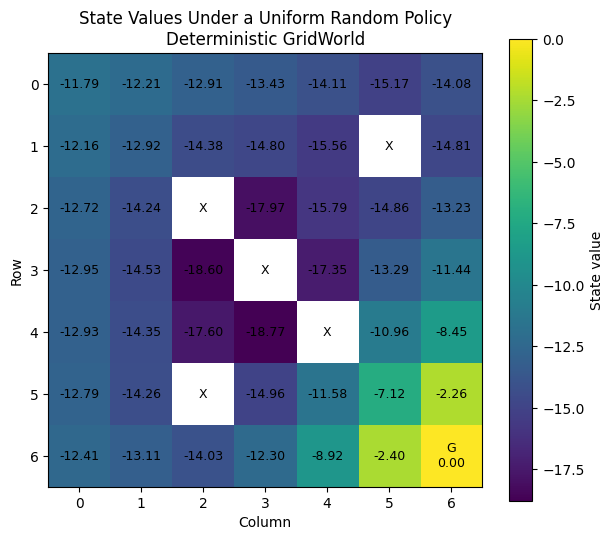

In [10]:
def plot_state_values(env, values, title):
    value_grid = np.full((env.size, env.size), np.nan)

    for state, value in values.items():
        value_grid[state] = value

    fig, ax = plt.subplots(figsize=(7, 6))
    image = ax.imshow(value_grid)

    for row in range(env.size):
        for col in range(env.size):
            state = (row, col)

            if state in env.obstacles:
                label = "X"
            elif state == env.goal_state:
                label = "G\n0.00"
            else:
                label = f"{values[state]:.2f}"

            ax.text(col, row, label, ha="center", va="center", fontsize=9)

    ax.set_xticks(range(env.size))
    ax.set_yticks(range(env.size))
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label="State value")
    plt.show()

plot_state_values(det_env, V_det, "State Values Under a Uniform Random Policy\nDeterministic GridWorld")

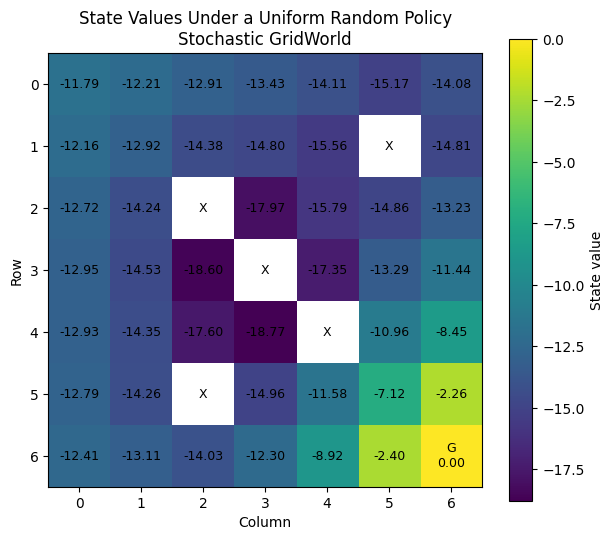

In [11]:
plot_state_values(stoch_env, V_stoch, "State Values Under a Uniform Random Policy\nStochastic GridWorld")

In [12]:
selected_states = [(0, 0), (2, 1), (4, 1), (5, 6), (6, 5), (6, 6)]

comparison = pd.DataFrame({
    "State": selected_states,
    "Deterministic V^pi": [V_det[s] for s in selected_states],
    "Stochastic V^pi": [V_stoch[s] for s in selected_states],
})

comparison["Difference (Det - Stoch)"] = (
    comparison["Deterministic V^pi"] - comparison["Stochastic V^pi"]
)

comparison.round(3)

,State,Deterministic V^pi,Stochastic V^pi,Difference (Det - Stoch)
0,"(0, 0)",-11.787,-11.787,0.0
1,"(2, 1)",-14.243,-14.243,-0.0
2,"(4, 1)",-14.348,-14.348,0.0
3,"(5, 6)",-2.263,-2.263,0.0
4,"(6, 5)",-2.399,-2.399,0.0
5,"(6, 6)",0.000,0.000,0.0


## 9. Action-Value Function $Q^\pi(s,a)$

The action-value function is

$$
\boxed{
Q^\pi(s,a)
=
\mathbb{E}_\pi[G_t\mid S_t=s,A_t=a]
}
$$

For a stochastic transition model,

$$
\boxed{
Q^\pi(s,a)
=
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V^\pi(s')
\right]
}
$$

For deterministic dynamics, one next state has probability $1$, so the equation reduces to

$$
\boxed{
Q^\pi(s,a)
=
R(s,a,s')
+
\gamma V^\pi(s')
}
$$

In [13]:
def q_from_state_values(env, values, state, action, gamma=0.9):
    q_value = 0.0
    components = []

    for probability, next_state, reward, done in env.transition_distribution(state, action):
        future_value = 0.0 if done else values[next_state]
        weighted_component = probability * (reward + gamma * future_value)
        q_value += weighted_component

        components.append({
            "probability": probability,
            "next_state": next_state,
            "reward": reward,
            "future_value": future_value,
            "weighted_component": weighted_component,
        })

    return q_value, components

q_demo_state = (5, 6)
q_demo_action = "Down"

q_det, det_components = q_from_state_values(det_env, V_det, q_demo_state, q_demo_action)
q_stoch, stoch_components = q_from_state_values(stoch_env, V_stoch, q_demo_state, q_demo_action)

print("Deterministic Q^pi calculation")
for item in det_components:
    print(
        f"  P={item['probability']:.2f}, next_state={item['next_state']}, "
        f"reward={item['reward']}, V(next)={item['future_value']:.3f}, "
        f"weighted term={item['weighted_component']:.3f}"
    )
print(f"  Q^pi({q_demo_state}, {q_demo_action}) = {q_det:.6f}")

print("\nStochastic Q^pi calculation")
for item in stoch_components:
    print(
        f"  P={item['probability']:.2f}, next_state={item['next_state']}, "
        f"reward={item['reward']}, V(next)={item['future_value']:.3f}, "
        f"weighted term={item['weighted_component']:.3f}"
    )
print(f"  Q^pi({q_demo_state}, {q_demo_action}) = {q_stoch:.6f}")

Deterministic Q^pi calculation
  P=1.00, next_state=(6, 6), reward=10, V(next)=0.000, weighted term=10.000
  Q^pi((5, 6), Down) = 10.000000

Stochastic Q^pi calculation
  P=0.10, next_state=(5, 5), reward=-1, V(next)=-7.121, weighted term=-0.741
  P=0.10, next_state=(5, 6), reward=-1, V(next)=-2.263, weighted term=-0.304
  P=0.80, next_state=(6, 6), reward=10, V(next)=0.000, weighted term=8.000
  Q^pi((5, 6), Down) = 6.955517


### 9.1 Relationship Between State and Action Values

The state value is the policy-weighted average of the action values:

$$
\boxed{
V^\pi(s)=\sum_a\pi(a|s)Q^\pi(s,a)
}
$$

Under the uniform random policy,

$$
V^\pi(s)
=
\frac14
\sum_a Q^\pi(s,a).
$$

In [14]:
def action_values(env, values, state, gamma=0.9):
    return {
        action: q_from_state_values(env, values, state, action, gamma)[0]
        for action in env.action_space
    }

state = (5, 6)

for label, env, values in [
    ("Deterministic", det_env, V_det),
    ("Stochastic", stoch_env, V_stoch),
]:
    q_values = action_values(env, values, state)
    weighted_average = np.mean(list(q_values.values()))

    print(label)
    for action, value in q_values.items():
        print(f"  {action:<5}: Q^pi={value:.3f}")

    print(f"  Average Q^pi = {weighted_average:.6f}")
    print(f"  Stored V^pi = {values[state]:.6f}")
    print(f"  Difference = {abs(weighted_average - values[state]):.12f}\n")

Deterministic
  Up   : Q^pi=-8.606
  Down : Q^pi=10.000
  Left : Q^pi=-7.408
  Right: Q^pi=-3.036
  Average Q^pi = -2.262615
  Stored V^pi = -2.262615
  Difference = 0.000000000026

Stochastic
  Up   : Q^pi=-7.929
  Down : Q^pi=6.956
  Left : Q^pi=-5.787
  Right: Q^pi=-2.290
  Average Q^pi = -2.262615
  Stored V^pi = -2.262615
  Difference = 0.000000000026



## 10. Bellman Expectation Equation

The general Bellman expectation equation is

$$
\boxed{
V^\pi(s)
=
\sum_a
\pi(a|s)
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V^\pi(s')
\right]
}
$$

The deterministic equation is not a different principle. It is simply the special case in which the transition distribution for an action contains one next state with probability $1$.

In [15]:
state = (5, 6)

for label, env, values in [
    ("Deterministic", det_env, V_det),
    ("Stochastic", stoch_env, V_stoch),
]:
    policy = uniform_random_policy(env, state)
    bellman_rhs = 0.0

    for action, action_probability in policy.items():
        q_value, _ = q_from_state_values(env, values, state, action)
        bellman_rhs += action_probability * q_value

    print(label)
    print(f"  Bellman RHS = {bellman_rhs:.6f}")
    print(f"  Stored V^pi = {values[state]:.6f}")
    print(f"  Absolute difference = {abs(bellman_rhs - values[state]):.12f}\n")

Deterministic
  Bellman RHS = -2.262615
  Stored V^pi = -2.262615
  Absolute difference = 0.000000000026

Stochastic
  Bellman RHS = -2.262615
  Stored V^pi = -2.262615
  Absolute difference = 0.000000000026



## 11. Optimal Value Functions and Optimal Policy

The optimal state-value function is

$$
\boxed{
V^*(s)=\max_\pi V^\pi(s)
}
$$

and the optimal action-value function is

$$
\boxed{
Q^*(s,a)=\max_\pi Q^\pi(s,a)
}
$$

They satisfy

$$
\boxed{
V^*(s)=\max_a Q^*(s,a)
}
$$

and an optimal policy selects an action that attains this maximum:

$$
\boxed{
\pi_*(s)\in\arg\max_a Q^*(s,a)
}
$$

## 12. Bellman Optimality Equation and Value Iteration

For a general MDP,

$$
\boxed{
V^*(s)
=
\max_a
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V^*(s')
\right]
}
$$

Value iteration repeatedly applies this optimal Bellman backup:

$$
V_{k+1}(s)
=
\max_a
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V_k(s')
\right].
$$

Unlike taking the maximum over $Q^\pi$ computed from a random-policy value function, value iteration actually solves for the optimal value function.

In [16]:
def value_iteration(env, gamma=0.9, tolerance=1e-10, max_iterations=10000):
    values = {state: 0.0 for state in env.state_space}

    for iteration in range(1, max_iterations + 1):
        new_values = values.copy()
        delta = 0.0

        for state in env.state_space:
            if state == env.goal_state:
                new_values[state] = 0.0
                continue

            q_values = action_values(env, values, state, gamma)
            best_value = max(q_values.values())

            new_values[state] = best_value
            delta = max(delta, abs(best_value - values[state]))

        values = new_values

        if delta < tolerance:
            return values, iteration

    raise RuntimeError("Value iteration did not converge.")

def extract_optimal_policy(env, values, gamma=0.9, tolerance=1e-10):
    policy = {}

    for state in env.state_space:
        if state == env.goal_state:
            policy[state] = []
            continue

        q_values = action_values(env, values, state, gamma)
        best_value = max(q_values.values())

        policy[state] = [
            action
            for action, value in q_values.items()
            if abs(value - best_value) <= tolerance
        ]

    return policy

V_star_det, vi_sweeps_det = value_iteration(det_env)
V_star_stoch, vi_sweeps_stoch = value_iteration(stoch_env)

policy_star_det = extract_optimal_policy(det_env, V_star_det)
policy_star_stoch = extract_optimal_policy(stoch_env, V_star_stoch)

print("Deterministic value-iteration sweeps:", vi_sweeps_det)
print("Stochastic value-iteration sweeps:", vi_sweeps_stoch)

Deterministic value-iteration sweeps: 13
Stochastic value-iteration sweeps: 52


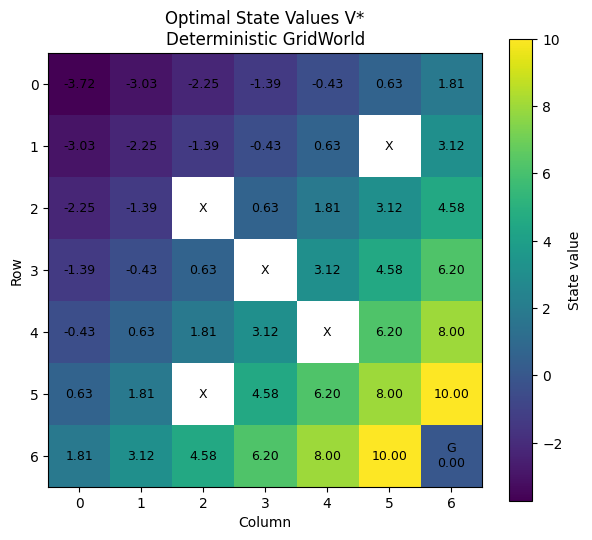

In [17]:
plot_state_values(det_env, V_star_det, "Optimal State Values V*\nDeterministic GridWorld")

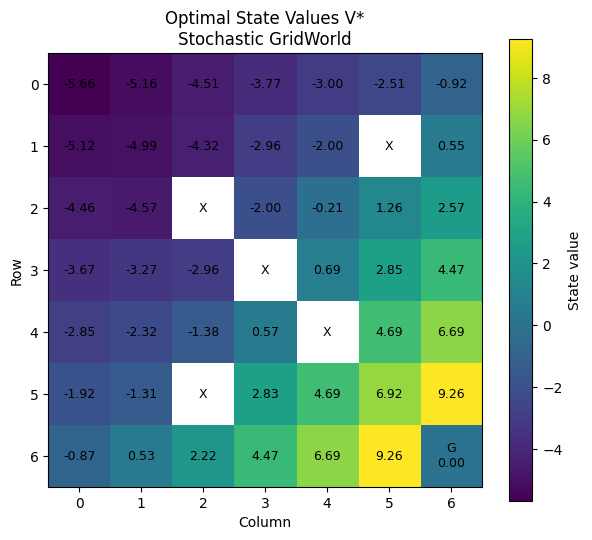

In [18]:
plot_state_values(stoch_env, V_star_stoch, "Optimal State Values V*\nStochastic GridWorld")

In [19]:
optimal_comparison = pd.DataFrame({
    "State": selected_states,
    "Deterministic V*": [V_star_det[s] for s in selected_states],
    "Stochastic V*": [V_star_stoch[s] for s in selected_states],
})

optimal_comparison["Difference (Det - Stoch)"] = (
    optimal_comparison["Deterministic V*"] - optimal_comparison["Stochastic V*"]
)

optimal_comparison.round(3)

,State,Deterministic V*,Stochastic V*,Difference (Det - Stoch)
0,"(0, 0)",-3.724,-5.659,1.935
1,"(2, 1)",-1.391,-4.566,3.176
2,"(4, 1)",0.629,-2.324,2.953
3,"(5, 6)",10.000,9.256,0.744
4,"(6, 5)",10.000,9.256,0.744
5,"(6, 6)",0.000,0.000,0.000


### 12.1 Visualize the Optimal Policies

Arrows show the maximizing action or actions in each state. Multiple arrows indicate ties.

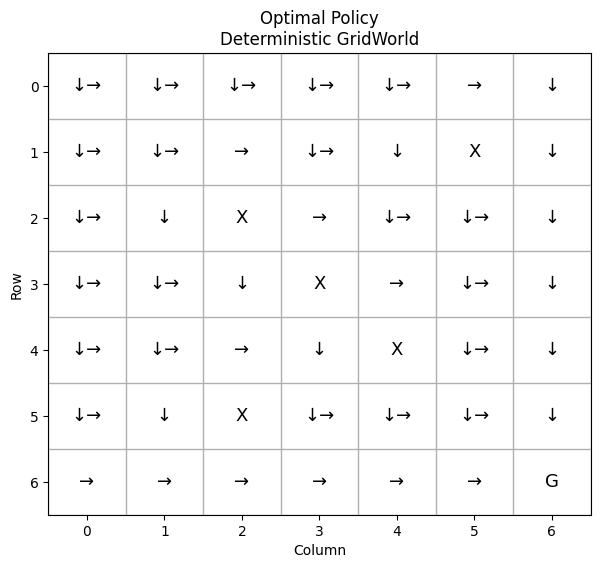

In [20]:
ARROWS = {
    "Up": "↑",
    "Down": "↓",
    "Left": "←",
    "Right": "→",
}

def plot_policy(env, policy, title):
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.set_xlim(-0.5, env.size - 0.5)
    ax.set_ylim(env.size - 0.5, -0.5)
    ax.set_xticks(range(env.size))
    ax.set_yticks(range(env.size))
    ax.set_xticks(np.arange(-0.5, env.size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, env.size, 1), minor=True)
    ax.grid(which="minor", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    for row in range(env.size):
        for col in range(env.size):
            state = (row, col)

            if state in env.obstacles:
                label = "X"
            elif state == env.goal_state:
                label = "G"
            else:
                label = "".join(ARROWS[a] for a in policy[state])

            ax.text(col, row, label, ha="center", va="center", fontsize=13)

    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    ax.set_title(title)
    plt.show()

plot_policy(det_env, policy_star_det, "Optimal Policy\nDeterministic GridWorld")

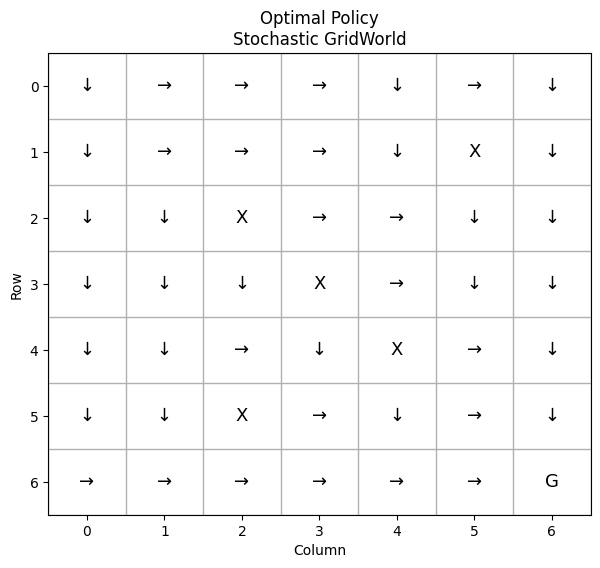

In [21]:
plot_policy(stoch_env, policy_star_stoch, "Optimal Policy\nStochastic GridWorld")

## 13. Manual Optimal Backup Comparison

Consider state $(5,6)$.

In the deterministic environment, action `Down` reaches the goal with certainty, so

$$
Q^*((5,6),\text{Down})=10.
$$

In the stochastic environment, the intended action can lead to several outcomes. Therefore,

$$
Q^*((5,6),\text{Down})
=
\sum_{s'}
P(s'|(5,6),\text{Down})
\left[
R+\gamma V^*(s')
\right].
$$

The following cell expands the stochastic terms explicitly.

In [22]:
state = (5, 6)
action = "Down"

q_det_star, det_star_components = q_from_state_values(
    det_env, V_star_det, state, action
)
q_stoch_star, stoch_star_components = q_from_state_values(
    stoch_env, V_star_stoch, state, action
)

print("Deterministic optimal backup")
for item in det_star_components:
    print(
        f"  {item['probability']:.2f} * "
        f"({item['reward']} + 0.9*{item['future_value']:.3f}) "
        f"= {item['weighted_component']:.3f}"
    )
print(f"  Q* = {q_det_star:.6f}")

print("\nStochastic optimal backup")
for item in stoch_star_components:
    print(
        f"  {item['probability']:.2f} * "
        f"({item['reward']} + 0.9*{item['future_value']:.3f}) "
        f"= {item['weighted_component']:.3f}"
    )
print(f"  Q* = {q_stoch_star:.6f}")

Deterministic optimal backup
  1.00 * (10 + 0.9*0.000) = 10.000
  Q* = 10.000000

Stochastic optimal backup
  0.10 * (-1 + 0.9*6.920) = 0.523
  0.10 * (-1 + 0.9*9.256) = 0.733
  0.80 * (10 + 0.9*0.000) = 8.000
  Q* = 9.255796


## 14. Exploration vs. Exploitation vs. Environmental Randomness

An $\epsilon$-greedy policy introduces **agent-side exploration**:

$$
\pi_\epsilon(a|s)
=
\begin{cases}
1-\epsilon+\dfrac{\epsilon}{|\mathcal A|},
& a=a^*,\\[6pt]
\dfrac{\epsilon}{|\mathcal A|},
& a\ne a^*.
\end{cases}
$$

The ideas are distinct:

- **Exploitation:** choose the current greedy action.
- **Exploration:** deliberately select non-greedy actions sometimes.
- **Environmental stochasticity:** even after the agent selects an action, the environment may produce different outcomes.

Exploration and transition uncertainty therefore should not be treated as the same source of randomness.

In [23]:
def epsilon_greedy_action(action_values, epsilon=0.1, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    actions = list(action_values.keys())

    if rng.random() < epsilon:
        return rng.choice(actions)

    return max(action_values, key=action_values.get)

state = (5, 6)
q_star_stoch = action_values(stoch_env, V_star_stoch, state)
best_action = max(q_star_stoch, key=q_star_stoch.get)

rng = np.random.default_rng(SEED)
epsilon = 0.1
samples = 1000

selection_counts = Counter(
    epsilon_greedy_action(q_star_stoch, epsilon=epsilon, rng=rng)
    for _ in range(samples)
)

print("State:", state)
print("Greedy intended action:", best_action)
print("epsilon:", epsilon)
print("\nAgent selections from 1,000 decisions:")

for action in stoch_env.action_space:
    count = selection_counts[action]
    print(f"  {action:<5}: {count:>4} ({count / samples:.1%})")

print("\nPossible environment outcomes after the greedy intended action:")
for probability, next_state, reward, done in stoch_env.transition_distribution(state, best_action):
    print(
        f"  P={probability:.2f} -> "
        f"next_state={next_state}, reward={reward}, done={done}"
    )

State: (5, 6)
Greedy intended action: Down
epsilon: 0.1

Agent selections from 1,000 decisions:
  Up   :   29 (2.9%)
  Down :  935 (93.5%)
  Left :   21 (2.1%)
  Right:   15 (1.5%)

Possible environment outcomes after the greedy intended action:
  P=0.10 -> next_state=(5, 5), reward=-1, done=False
  P=0.10 -> next_state=(5, 6), reward=-1, done=False
  P=0.80 -> next_state=(6, 6), reward=10, done=True


## 15. Deterministic vs. Stochastic GridWorld: Summary

| Concept | Deterministic GridWorld | Stochastic GridWorld |
|---|---|---|
| Transition model | One next state | Multiple possible next states |
| $P(s'|s,a)$ | Usually $0$ or $1$ | General probabilities |
| Repeating the same action | Same outcome | Outcome may differ |
| $Q^\pi(s,a)$ backup | One transition term | Probability-weighted sum |
| Bellman equation | One next state per action | Sum over next states |
| Policy | Can be deterministic or stochastic | Can be deterministic or stochastic |
| Exploration | Agent-side randomness | Agent-side randomness |
| Transition uncertainty | None | Present |

The key mathematical relationships are

$$
\boxed{
V^\pi(s)
=
\sum_a\pi(a|s)Q^\pi(s,a)
}
$$

$$
\boxed{
Q^\pi(s,a)
=
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V^\pi(s')
\right]
}
$$

$$
\boxed{
V^*(s)
=
\max_a
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V^*(s')
\right]
}
$$

The deterministic environment is therefore a special case of the same MDP equations used for the stochastic environment.